**Lifetime Value (LTV) Project**

This notebook focuses on forecasting Customer Lifetime Value (LTV) using historical transaction data. The dataset is transformed into time series sequences to capture temporal patterns and customer behavior over time.

Two forecasting approaches are explored:

*   Long Short-Term Memory (LSTM), a recurrent neural network designed for sequential data,
*   TimeFM, a foundation model for time series forecasting.

Their performance is evaluated to assess their effectiveness in projecting future customer value.

## Setup and Dependencies

### Library

Imports the libraries and dependencies required throughout the project.

In [126]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import auth
from google.colab import drive

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

### Auth

Authentication to google account and drive for more google cloud services access

In [127]:
drive.mount('/content/drive')

auth.authenticate_user()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Preparation

### Loader

Query for access data in Google BigQuery

Load data from bigquery

In [ ]:
df = pd.read_gbq(sql_query, project_id='', dialect='standard')
df.head()

/tmp/ipykernel_3585/893440209.py:1: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(sql_query, project_id='linkit-rnd-475909', dialect='standard')


,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total
0,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0
1,2025-01-01,MBP,2025-01-02,8,16000.0,DAILYPUSH,152000.0
2,2025-01-01,MBP,2025-01-03,18,36000.0,DAILYPUSH,188000.0
3,2025-01-01,MBP,2025-01-04,4,8000.0,DAILYPUSH,196000.0
4,2025-01-01,MBP,2025-01-05,7,14000.0,DAILYPUSH,210000.0


In [130]:
df.tail()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total
4548,2025-08-10,MBP,2026-01-02,1,2000.0,DAILYPUSH,1280000.0
4549,2025-08-10,MBP,2026-02-01,4,8000.0,DAILYPUSH,1288000.0
4550,2025-08-10,MBP,2026-02-02,6,12000.0,DAILYPUSH,1300000.0
4551,2025-08-10,MBP,2026-02-03,3,6000.0,DAILYPUSH,1306000.0
4552,2025-08-10,MBP,2026-02-10,0,0.0,PURGE,1306000.0


### Exploration

Compact information about data

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4553 entries, 0 to 4552
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date_created_at        4553 non-null   dbdate 
 1   adnet                  4553 non-null   object 
 2   date_update            4553 non-null   dbdate 
 3   no_of_user             4553 non-null   Int64  
 4   revenue_dailypush      4553 non-null   float64
 5   subject                4553 non-null   object 
 6   revenue_running_total  4553 non-null   float64
dtypes: Int64(1), dbdate(2), float64(2), object(2)
memory usage: 253.6+ KB


Checking unique value

In [132]:
unique_values = df.nunique()
print(unique_values)

date_created_at            30
adnet                       1
date_update               374
no_of_user                 60
revenue_dailypush          55
subject                     3
revenue_running_total    1190
dtype: int64


Checking cohort list

In [133]:
sorted(df['date_created_at'].unique())

[datetime.date(2025, 1, 1),
 datetime.date(2025, 1, 5),
 datetime.date(2025, 1, 12),
 datetime.date(2025, 1, 19),
 datetime.date(2025, 1, 26),
 datetime.date(2025, 2, 2),
 datetime.date(2025, 2, 9),
 datetime.date(2025, 2, 16),
 datetime.date(2025, 2, 23),
 datetime.date(2025, 3, 2),
 datetime.date(2025, 3, 5),
 datetime.date(2025, 3, 8),
 datetime.date(2025, 3, 12),
 datetime.date(2025, 3, 15),
 datetime.date(2025, 3, 17),
 datetime.date(2025, 3, 19),
 datetime.date(2025, 3, 21),
 datetime.date(2025, 3, 22),
 datetime.date(2025, 3, 24),
 datetime.date(2025, 3, 27),
 datetime.date(2025, 3, 29),
 datetime.date(2025, 4, 1),
 datetime.date(2025, 4, 2),
 datetime.date(2025, 4, 5),
 datetime.date(2025, 7, 14),
 datetime.date(2025, 7, 22),
 datetime.date(2025, 7, 28),
 datetime.date(2025, 8, 2),
 datetime.date(2025, 8, 6),
 datetime.date(2025, 8, 10)]

Checking duplicate data

In [134]:
df.duplicated().sum()

np.int64(0)

### Feature Engineering

Adding cohort age (date update - date created) for getting information day every cohort

In [135]:
df['cohort_age'] = (
    df['date_update'] -
    df['date_created_at']
).dt.days

In [136]:
df.head(10)

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age
0,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0
1,2025-01-01,MBP,2025-01-02,8,16000.0,DAILYPUSH,152000.0,1
2,2025-01-01,MBP,2025-01-03,18,36000.0,DAILYPUSH,188000.0,2
3,2025-01-01,MBP,2025-01-04,4,8000.0,DAILYPUSH,196000.0,3
4,2025-01-01,MBP,2025-01-05,7,14000.0,DAILYPUSH,210000.0,4
5,2025-01-01,MBP,2025-01-06,7,14000.0,DAILYPUSH,224000.0,5
6,2025-01-01,MBP,2025-01-07,9,18000.0,DAILYPUSH,242000.0,6
7,2025-01-01,MBP,2025-01-08,6,12000.0,DAILYPUSH,254000.0,7
8,2025-01-01,MBP,2025-01-09,7,14000.0,DAILYPUSH,268000.0,8
9,2025-01-01,MBP,2025-01-10,6,12000.0,DAILYPUSH,280000.0,9


Adding day of week using pandas format (Monday is starting from 0)

In [137]:
df['date_created_at'] = pd.to_datetime(df['date_created_at'])
df['date_update'] = pd.to_datetime(df['date_update'])

df['day_of_week'] = df['date_update'].dt.dayofweek

In [138]:
df.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age,day_of_week
0,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0,2
1,2025-01-01,MBP,2025-01-02,8,16000.0,DAILYPUSH,152000.0,1,3
2,2025-01-01,MBP,2025-01-03,18,36000.0,DAILYPUSH,188000.0,2,4
3,2025-01-01,MBP,2025-01-04,4,8000.0,DAILYPUSH,196000.0,3,5
4,2025-01-01,MBP,2025-01-05,7,14000.0,DAILYPUSH,210000.0,4,6


Checking data information

In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4553 entries, 0 to 4552
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date_created_at        4553 non-null   datetime64[ns]
 1   adnet                  4553 non-null   object        
 2   date_update            4553 non-null   datetime64[ns]
 3   no_of_user             4553 non-null   Int64         
 4   revenue_dailypush      4553 non-null   float64       
 5   subject                4553 non-null   object        
 6   revenue_running_total  4553 non-null   float64       
 7   cohort_age             4553 non-null   int64         
 8   day_of_week            4553 non-null   int32         
dtypes: Int64(1), datetime64[ns](2), float64(2), int32(1), int64(1), object(2)
memory usage: 306.9+ KB


### Visualization

Distribution of cohort length

In [140]:
cohort_length = (
    df.groupby('date_created_at')['cohort_age']
      .max()
      .add(1)
      .reset_index(name='cohort_length')
)

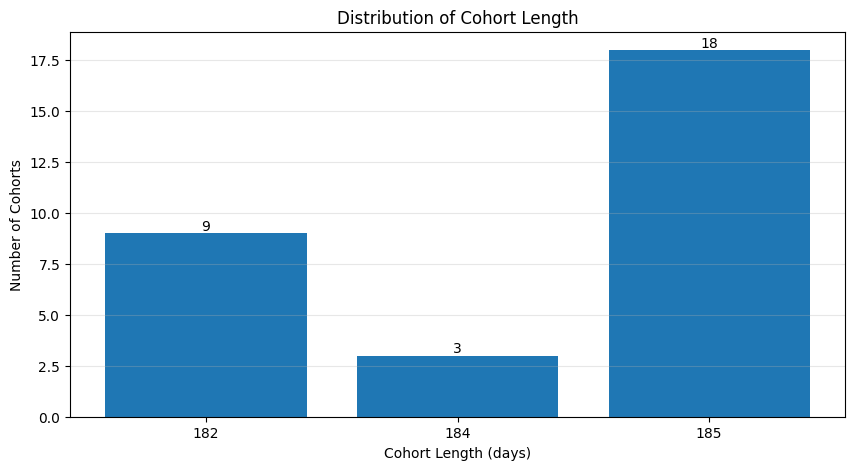

In [141]:
dist = (
    cohort_length['cohort_length']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    dist.index.astype(str),
    dist.values
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.xlabel('Cohort Length (days)')
plt.ylabel('Number of Cohorts')
plt.title('Distribution of Cohort Length')
plt.grid(axis='y', alpha=0.3)

plt.show()

Distribution of running revenue per cohort

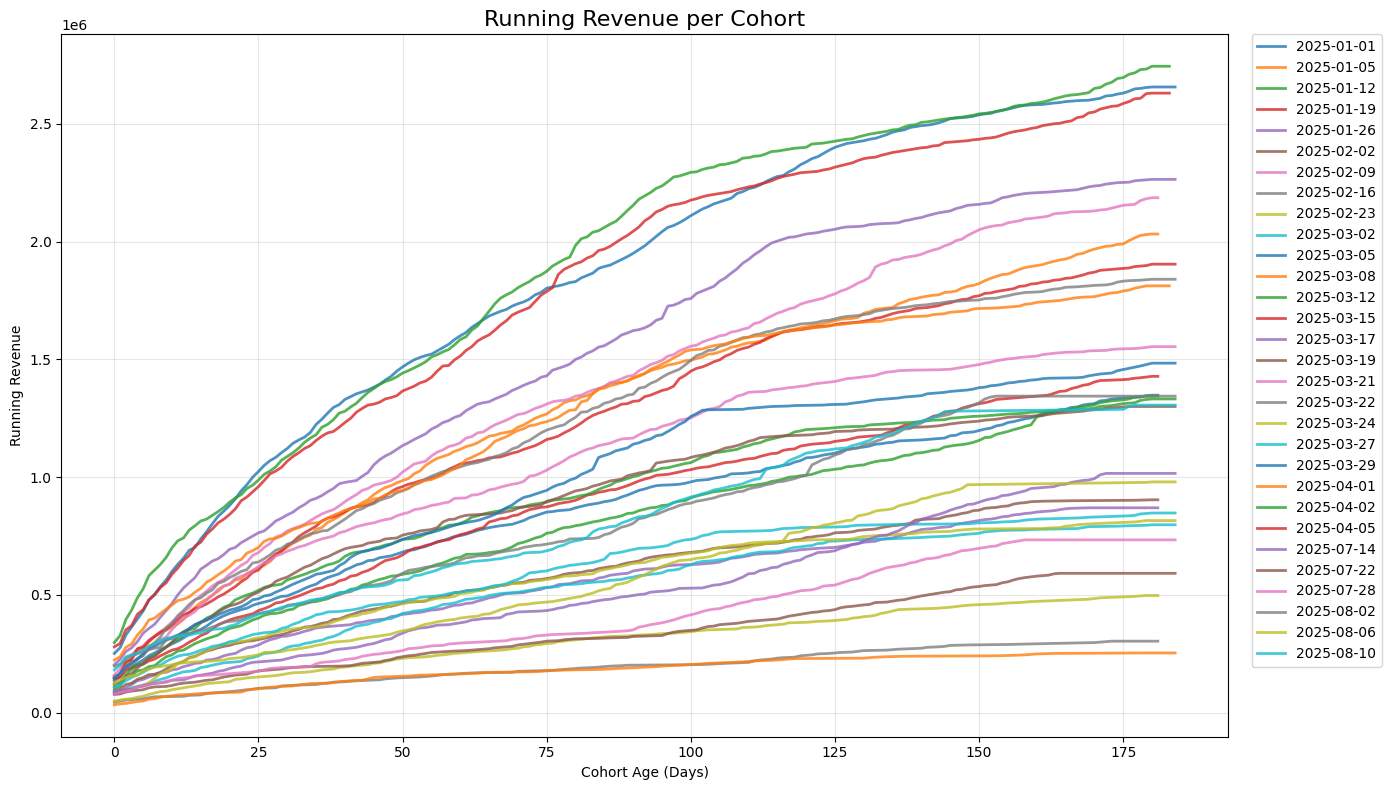

In [142]:
import matplotlib.pyplot as plt
import numpy as np

sample = (
    df['date_created_at']
    .drop_duplicates()
    .sample(30)
)

plt.figure(figsize=(14, 8))

for cohort in sorted(sample):
    temp = (
        df[df['date_created_at'] == cohort]
        .sort_values('cohort_age')
    )

    plt.plot(
        temp['cohort_age'],
        temp['revenue_running_total'],
        linewidth=2,
        alpha=0.8,
        label=cohort.strftime('%Y-%m-%d')
    )

plt.title("Running Revenue per Cohort", fontsize=16)
plt.xlabel("Cohort Age (Days)")
plt.ylabel("Running Revenue")
plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()

Average revenue daily push distribution per cohort age

<Axes: xlabel='cohort_age'>

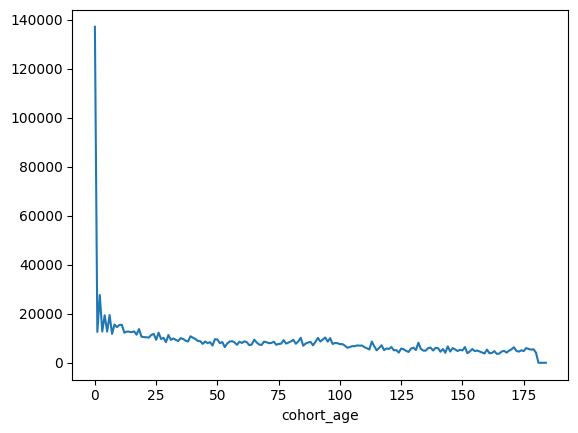

In [143]:
avg_daily = (
    df.groupby('cohort_age')['revenue_dailypush']
    .mean()
)

avg_daily.plot()

Average total revenue distribution per cohort age

<Axes: xlabel='cohort_age'>

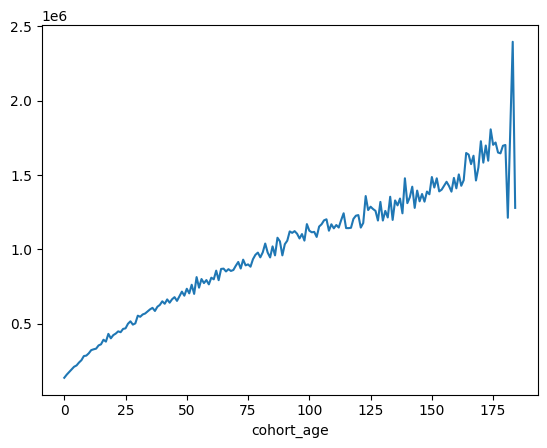

In [144]:
avg_running = (
    df.groupby('cohort_age')['revenue_running_total']
    .mean()
)

avg_running.plot()

Numerical correlation

<Axes: >

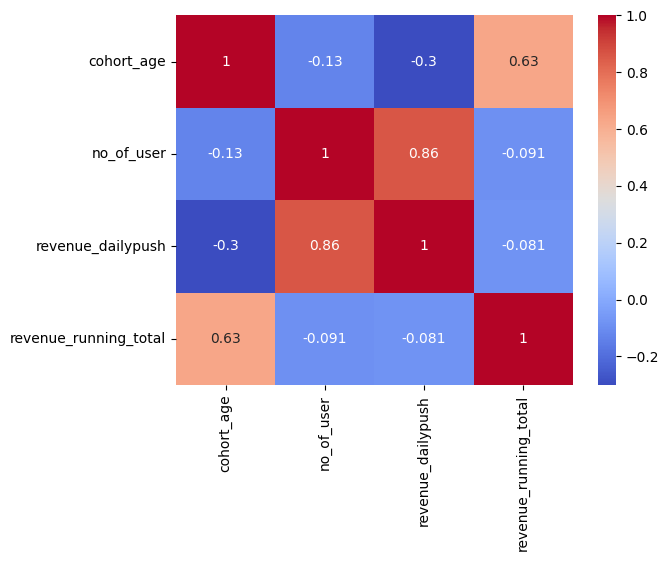

In [145]:
numeric_cols = [
    'cohort_age',
    'no_of_user',
    'revenue_dailypush',
    'revenue_running_total'
]

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

## Preprocessing

### Sort Data

Final preparation with sorting date created and cohort age

In [146]:
df = (
    df
    .sort_values(
        ['date_created_at', 'cohort_age']
    )
    .reset_index(drop=True)
)

In [147]:
df.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age,day_of_week
0,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0,2
1,2025-01-01,MBP,2025-01-02,8,16000.0,DAILYPUSH,152000.0,1,3
2,2025-01-01,MBP,2025-01-03,18,36000.0,DAILYPUSH,188000.0,2,4
3,2025-01-01,MBP,2025-01-04,4,8000.0,DAILYPUSH,196000.0,3,5
4,2025-01-01,MBP,2025-01-05,7,14000.0,DAILYPUSH,210000.0,4,6


### Encoding

Create new dataframe for preprocessing process

In [148]:
df_model = df.copy()

subject_encoder = LabelEncoder()
adnet_encoder = LabelEncoder()

Subject encoding

In [149]:
df_model['subject_encoded'] = subject_encoder.fit_transform(df_model['subject'])

In [150]:
df_model.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age,day_of_week,subject_encoded
0,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0,2,1
1,2025-01-01,MBP,2025-01-02,8,16000.0,DAILYPUSH,152000.0,1,3,0
2,2025-01-01,MBP,2025-01-03,18,36000.0,DAILYPUSH,188000.0,2,4,0
3,2025-01-01,MBP,2025-01-04,4,8000.0,DAILYPUSH,196000.0,3,5,0
4,2025-01-01,MBP,2025-01-05,7,14000.0,DAILYPUSH,210000.0,4,6,0


Adnet encoding

In [151]:
df_model['adnet_encoded'] = adnet_encoder.fit_transform(df_model['adnet'])

In [152]:
df_model.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age,day_of_week,subject_encoded,adnet_encoded
0,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0,2,1,0
1,2025-01-01,MBP,2025-01-02,8,16000.0,DAILYPUSH,152000.0,1,3,0,0
2,2025-01-01,MBP,2025-01-03,18,36000.0,DAILYPUSH,188000.0,2,4,0,0
3,2025-01-01,MBP,2025-01-04,4,8000.0,DAILYPUSH,196000.0,3,5,0,0
4,2025-01-01,MBP,2025-01-05,7,14000.0,DAILYPUSH,210000.0,4,6,0,0


### Feature Selection

Selecting feature for new dataframe

In [153]:
KEEP_COLS = [
    'date_created_at',
    'cohort_age',
    'revenue_running_total',
    'revenue_dailypush',
    'no_of_user',
    'day_of_week',
    'subject_encoded',
    'adnet_encoded'
]

df_model = df_model[KEEP_COLS]

In [154]:
df_model.head()

,date_created_at,cohort_age,revenue_running_total,revenue_dailypush,no_of_user,day_of_week,subject_encoded,adnet_encoded
0,2025-01-01,0,136000.0,136000.0,686,2,1,0
1,2025-01-01,1,152000.0,16000.0,8,3,0,0
2,2025-01-01,2,188000.0,36000.0,18,4,0,0
3,2025-01-01,3,196000.0,8000.0,4,5,0,0
4,2025-01-01,4,210000.0,14000.0,7,6,0,0


### Split Data

Split to train 80% and validation 20% from total cohorts

In [155]:
cohorts = sorted(df_model['date_created_at'].unique())

split_idx = int(len(cohorts) * 0.8)

train_cohorts = cohorts[:split_idx]
val_cohorts = cohorts[split_idx:]

In [156]:
print("Total Train Cohort:", len(train_cohorts))
print("Sample Train Cohort:", train_cohorts)

print("Total Val Cohort:", len(val_cohorts))
print("Sample Val Cohort:", val_cohorts)

Total Train Cohort: 24
Sample Train Cohort: [Timestamp('2025-01-01 00:00:00'), Timestamp('2025-01-05 00:00:00'), Timestamp('2025-01-12 00:00:00'), Timestamp('2025-01-19 00:00:00'), Timestamp('2025-01-26 00:00:00'), Timestamp('2025-02-02 00:00:00'), Timestamp('2025-02-09 00:00:00'), Timestamp('2025-02-16 00:00:00'), Timestamp('2025-02-23 00:00:00'), Timestamp('2025-03-02 00:00:00'), Timestamp('2025-03-05 00:00:00'), Timestamp('2025-03-08 00:00:00'), Timestamp('2025-03-12 00:00:00'), Timestamp('2025-03-15 00:00:00'), Timestamp('2025-03-17 00:00:00'), Timestamp('2025-03-19 00:00:00'), Timestamp('2025-03-21 00:00:00'), Timestamp('2025-03-22 00:00:00'), Timestamp('2025-03-24 00:00:00'), Timestamp('2025-03-27 00:00:00'), Timestamp('2025-03-29 00:00:00'), Timestamp('2025-04-01 00:00:00'), Timestamp('2025-04-02 00:00:00'), Timestamp('2025-04-05 00:00:00')]
Total Val Cohort: 6
Sample Val Cohort: [Timestamp('2025-07-14 00:00:00'), Timestamp('2025-07-22 00:00:00'), Timestamp('2025-07-28 00:00:00'

Insert to pandas for next step (scaling)

In [157]:
train_df = df_model[df_model['date_created_at'].isin(train_cohorts)]
val_df = df_model[df_model['date_created_at'].isin(val_cohorts)]

In [158]:
train_df.head()

,date_created_at,cohort_age,revenue_running_total,revenue_dailypush,no_of_user,day_of_week,subject_encoded,adnet_encoded
0,2025-01-01,0,136000.0,136000.0,686,2,1,0
1,2025-01-01,1,152000.0,16000.0,8,3,0,0
2,2025-01-01,2,188000.0,36000.0,18,4,0,0
3,2025-01-01,3,196000.0,8000.0,4,5,0,0
4,2025-01-01,4,210000.0,14000.0,7,6,0,0


### Scaling

Setup feature and target for training

In [159]:
# Target changed to revenue_dailypush (daily increment, not cumulative)
# Easier to forecast recursively — avoids scaler drift on ever-growing values
# running total is recovered at inference via cumsum

FEATURES = [
    'revenue_dailypush',   # target & main signal
    'cohort_age',          # position in cohort lifecycle (known in future: +1 each step)
    'day_of_week',         # weekly seasonality (known in future: calendar)
]

TARGET = 'revenue_dailypush'

Separate scalers for features and target so inverse-transform is unambiguous

In [160]:
feature_scaler = MinMaxScaler()
target_scaler  = MinMaxScaler()

# Fit on train only
train_df = train_df.copy()
val_df   = val_df.copy()

train_df[FEATURES] = feature_scaler.fit_transform(train_df[FEATURES])
val_df[FEATURES]   = feature_scaler.transform(val_df[FEATURES])

# Separate target scaler (TARGET is also inside FEATURES[0], but scaler is fit separately)
train_df[TARGET] = target_scaler.fit_transform(train_df[[TARGET]])
val_df[TARGET]   = target_scaler.transform(val_df[[TARGET]])

Checking data train

In [161]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3707 entries, 0 to 3706
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date_created_at        3707 non-null   datetime64[ns]
 1   cohort_age             3707 non-null   float64       
 2   revenue_running_total  3707 non-null   float64       
 3   revenue_dailypush      3707 non-null   float64       
 4   no_of_user             3707 non-null   Int64         
 5   day_of_week            3707 non-null   float64       
 6   subject_encoded        3707 non-null   int64         
 7   adnet_encoded          3707 non-null   int64         
dtypes: Int64(1), datetime64[ns](1), float64(4), int64(2)
memory usage: 264.3 KB


In [162]:
train_df.head()

,date_created_at,cohort_age,revenue_running_total,revenue_dailypush,no_of_user,day_of_week,subject_encoded,adnet_encoded
0,2025-01-01,0.000000,136000.0,0.456376,686,0.333333,1,0
1,2025-01-01,0.005435,152000.0,0.053691,8,0.500000,0,0
2,2025-01-01,0.010870,188000.0,0.120805,18,0.666667,0,0
3,2025-01-01,0.016304,196000.0,0.026846,4,0.833333,0,0
4,2025-01-01,0.021739,210000.0,0.046980,7,1.000000,0,0


Checking data validation

In [163]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 846 entries, 3707 to 4552
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date_created_at        846 non-null    datetime64[ns]
 1   cohort_age             846 non-null    float64       
 2   revenue_running_total  846 non-null    float64       
 3   revenue_dailypush      846 non-null    float64       
 4   no_of_user             846 non-null    Int64         
 5   day_of_week            846 non-null    float64       
 6   subject_encoded        846 non-null    int64         
 7   adnet_encoded          846 non-null    int64         
dtypes: Int64(1), datetime64[ns](1), float64(4), int64(2)
memory usage: 60.3 KB


In [164]:
val_df.head()

,date_created_at,cohort_age,revenue_running_total,revenue_dailypush,no_of_user,day_of_week,subject_encoded,adnet_encoded
3707,2025-07-14,0.000000,88000.0,0.295302,1244,0.000000,1,0
3708,2025-07-14,0.010870,98000.0,0.033557,5,0.333333,0,0
3709,2025-07-14,0.016304,100000.0,0.006711,1,0.500000,0,0
3710,2025-07-14,0.021739,108000.0,0.026846,4,0.666667,0,0
3711,2025-07-14,0.027174,114000.0,0.020134,3,0.833333,0,0


## Sequence Generation

### Sliding Window

Setup window size with 30 days and build sequence per cohort

In [165]:
WINDOW_SIZE = 30

def create_sequences(data, features, target, window_size):

    X = []
    y = []

    for cohort in data['date_created_at'].unique():

        cohort_df = (data[data['date_created_at'] == cohort].sort_values('cohort_age'))
        feature_values = cohort_df[features].values
        target_values = cohort_df[target].values

        for i in range(len(cohort_df) - window_size):

            X.append(feature_values[i:i+window_size])
            y.append(target_values[i+window_size])

    return np.array(X), np.array(y)

### Generate Sequence

In [166]:
X_train, y_train = create_sequences(
    train_df,
    FEATURES,
    TARGET,
    WINDOW_SIZE
)

X_val, y_val = create_sequences(
    val_df,
    FEATURES,
    TARGET,
    WINDOW_SIZE
)

Checking shape sequence

In [167]:
print(X_train.shape)
print(y_train.shape)

print(X_val.shape)
print(y_val.shape)

(2987, 30, 3)
(2987,)
(666, 30, 3)
(666,)


## Modeling

### LSTM

Building model

In [168]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [169]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Compiler

In [170]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mape']
)

Training

In [171]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=50,
    verbose=1
)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0012 - mape: 204814.6562 - val_loss: 2.3773e-04 - val_mape: 125913.3906
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.7161e-04 - mape: 90912.4844 - val_loss: 2.0644e-04 - val_mape: 158477.8594
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.2799e-04 - mape: 112521.7578 - val_loss: 2.1782e-04 - val_mape: 133214.6562
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.8549e-04 - mape: 124050.4609 - val_loss: 1.9679e-04 - val_mape: 156316.7188
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.6678e-04 - mape: 89008.2812 - val_loss: 2.4246e-04 - val_mape: 130015.4219
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.7051e-04 - mape: 123731.7266 - val_loss: 2.0515e-04 - val_mape: 182228.5312
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 2.4830e-04 - mape: 111910.3516 - val_loss: 1.8761e-04 - val_mape: 190516.4062
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/s

## Evaluation

### Visualization

Loss visualization from training process

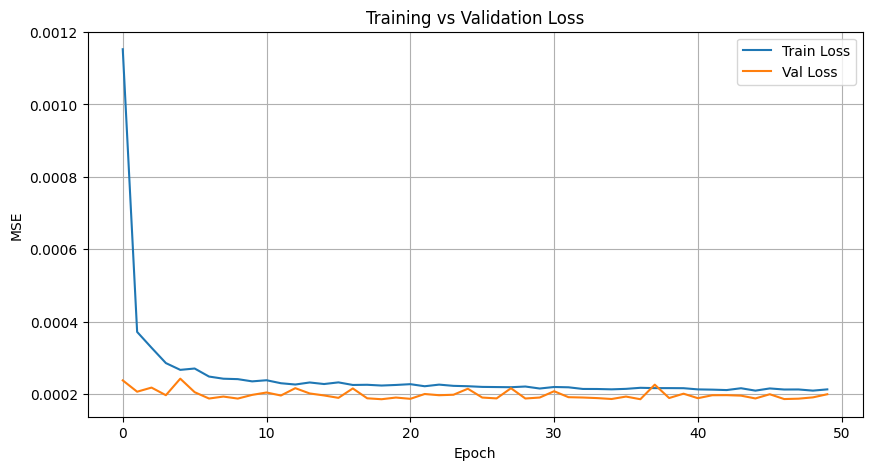

In [172]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

plt.show()

MAPE visualization from training process

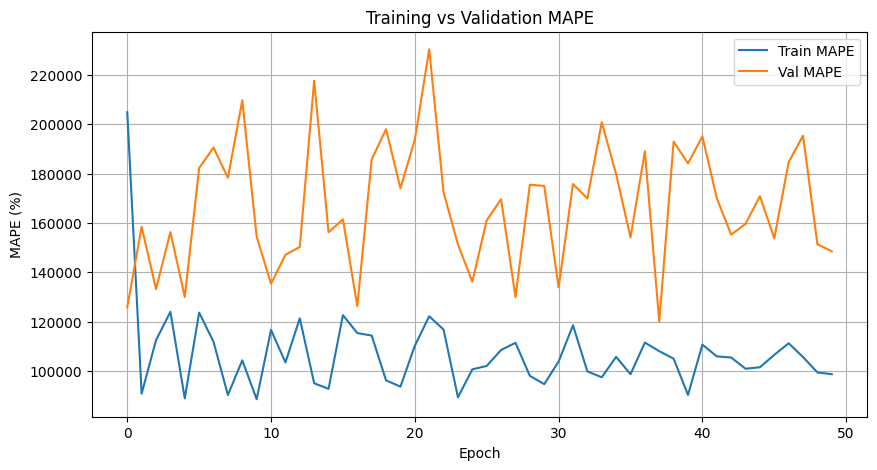

In [173]:
plt.figure(figsize=(10,5))

plt.plot(history.history['mape'], label='Train MAPE')
plt.plot(history.history['val_mape'], label='Val MAPE')

plt.title('Training vs Validation MAPE')
plt.xlabel('Epoch')
plt.ylabel('MAPE (%)')
plt.legend()
plt.grid(True)

plt.show()

In [174]:
y_pred = model.predict(X_val)
y_pred = y_pred.flatten()

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


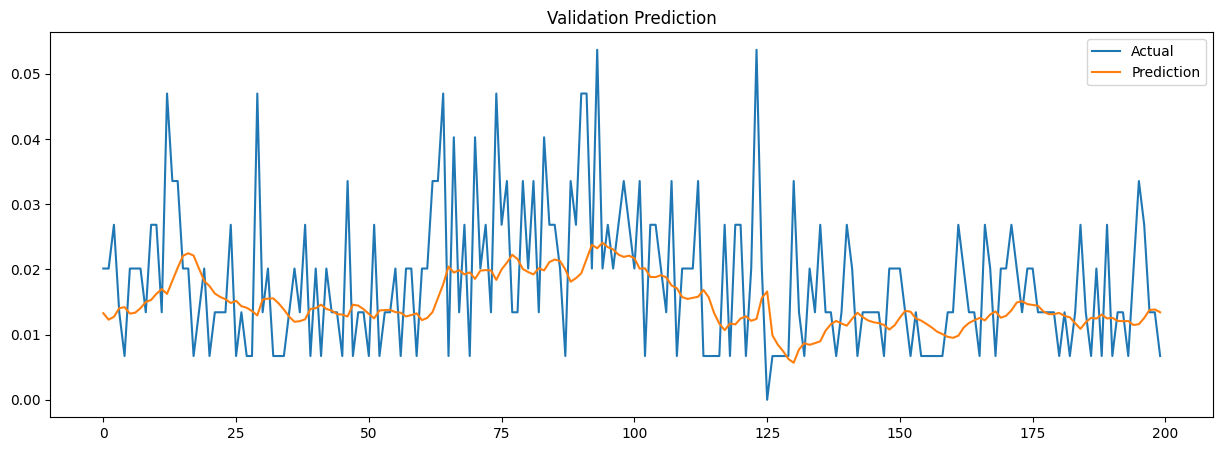

In [175]:
plt.figure(figsize=(15,5))

plt.plot(
    y_val[:200],
    label='Actual'
)

plt.plot(
    y_pred[:200],
    label='Prediction'
)

plt.title('Validation Prediction')

plt.legend()

plt.show()

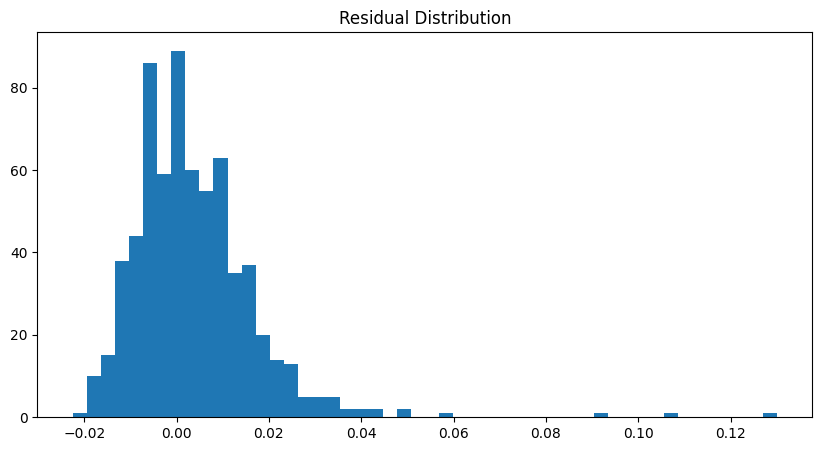

In [176]:
residuals = y_val - y_pred

plt.figure(figsize=(10,5))

plt.hist(
    residuals,
    bins=50
)

plt.title('Residual Distribution')

plt.show()

### Metrics

Detail evaluation metrics in MAE, RMSE, MAPE

In [177]:
mae = mean_absolute_error(
    y_val,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred
    )
)

mape = mean_absolute_percentage_error(
    y_val,
    y_pred
) * 100

In [178]:
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 0.009494
RMSE : 0.014123
MAPE : 66862701179977.87%


## Projection

Recursive forecast: first `SEED_DAYS` as input seed, predict all remaining days in the cohort

In [179]:
def forecast_recursive(model, seed_window, future_features_scaled):
    """
    Recursive 1-step forecast.
    - seed_window           : (WINDOW_SIZE, n_features) scaled, last WINDOW_SIZE rows of seed
    - future_features_scaled: (n_steps, n_features) scaled — known-future columns
                              (cohort_age, day_of_week) are pre-filled; target col starts as 0
    Returns predicted target values (scaled).
    """
    window = seed_window.copy()
    preds  = []
    target_idx = FEATURES.index(TARGET)

    for i in range(len(future_features_scaled)):

        x = window.reshape(1, window.shape[0], window.shape[1])
        next_val_scaled = model.predict(x, verbose=0)[0, 0]

        preds.append(next_val_scaled)

        # Fill predicted target into the pre-built future row
        next_step = future_features_scaled[i].copy()
        next_step[target_idx] = next_val_scaled

        window = np.vstack([window[1:], next_step])

    return np.array(preds)

Select cohort and run projection

In [180]:
SEED_DAYS = 90   # first 90 days used as input seed

# Need cohort with >= SEED_DAYS days of data
candidates = [
    c for c in val_cohorts
    if int(val_df[val_df['date_created_at'] == c]['cohort_age'].max()) >= SEED_DAYS
]

print("Eligible cohorts:", len(candidates))

cohort = candidates[0]

cohort_df = (
    val_df[val_df['date_created_at'] == cohort]
    .sort_values('cohort_age')
    .reset_index(drop=True)
)

# Seed: first SEED_DAYS rows
seed_df   = cohort_df[cohort_df['cohort_age'] < SEED_DAYS]
future_df = cohort_df[cohort_df['cohort_age'] >= SEED_DAYS].reset_index(drop=True)
n_steps   = len(future_df)

seed = seed_df[FEATURES].values[-WINDOW_SIZE:]

# Future feature matrix — cohort_age and day_of_week are already in val_df (known values)
# Target column will be filled step-by-step in forecast_recursive
future_features_scaled = future_df[FEATURES].values.copy()
future_features_scaled[:, FEATURES.index(TARGET)] = 0   # placeholder for target

print("Cohort      :", cohort)
print("Seed days   :", len(seed_df))
print("Future days :", n_steps)

# Recursive forecast
pred_scaled = forecast_recursive(model, seed, future_features_scaled)

# Inverse-transform daily push
pred_daily   = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
actual_daily = target_scaler.inverse_transform(future_df[[TARGET]].values).flatten()

# Recover running total via cumsum from last seed value
last_running = df[
    (df['date_created_at'] == cohort) &
    (df['cohort_age'] == SEED_DAYS - 1)
]['revenue_running_total'].values[0]

pred_running   = last_running + np.cumsum(pred_daily)
actual_running = df[
    (df['date_created_at'] == cohort) &
    (df['cohort_age'] >= SEED_DAYS)
].sort_values('cohort_age')['revenue_running_total'].values

print(f"Predicted running total at day {SEED_DAYS + n_steps - 1}: {pred_running[-1]:,.0f}")
print(f"Actual   running total at day {SEED_DAYS + n_steps - 1}: {actual_running[-1]:,.0f}")

Eligible cohorts: 0


IndexError: list index out of range

Evaluation at day+30, day+60, and full horizon

In [ ]:
milestones = {'day+30': 30, 'day+60': 60, 'full': n_steps}

for label, days in milestones.items():
    n = min(days, len(actual_running), len(pred_running))
    if n == 0:
        print(f"{label}: not enough data")
        continue
    mae  = mean_absolute_error(actual_running[:n], pred_running[:n])
    rmse = np.sqrt(mean_squared_error(actual_running[:n], pred_running[:n]))
    mape = mean_absolute_percentage_error(actual_running[:n], pred_running[:n]) * 100
    print(f"[{label:>7}] MAE={mae:>12,.0f}  RMSE={rmse:>12,.0f}  MAPE={mape:.2f}%")

Actual vs projection visualization

In [ ]:
# Actual seed running total (from original df, not scaled)
seed_running = df[
    (df['date_created_at'] == cohort) &
    (df['cohort_age'] < SEED_DAYS)
].sort_values('cohort_age')['revenue_running_total'].values

seed_age   = seed_df['cohort_age'].values
future_age = future_df['cohort_age'].values
pred_age   = future_age[:len(pred_running)]

plt.figure(figsize=(15, 5))

plt.plot(seed_age,   seed_running,   label='Actual (seed 0-89)',  color='steelblue')
plt.plot(future_age, actual_running, label='Actual (future)',      color='green')
plt.plot(pred_age,   pred_running,   label='Projection',           color='tomato', linestyle='--')

for offset, color in [(30, 'orange'), (60, 'purple')]:
    day = SEED_DAYS + offset - 1
    if len(future_age) > 0 and day <= future_age[-1]:
        plt.axvline(x=day, color=color, linestyle=':', alpha=0.7, label=f'day+{offset}')

plt.axvline(x=SEED_DAYS, color='gray', linestyle=':', alpha=0.7, label='seed end')
plt.title(f'LTV Projection (Running Total) — Cohort {str(cohort)[:10]}')
plt.xlabel('Cohort Age (Days)')
plt.ylabel('Running Revenue')
plt.legend()
plt.grid(alpha=0.3)

plt.show()